# Pipeline 1 — FCN (Fully Convolutional Network) for Pathology Segmentation

**Task:** Binary semantic segmentation of tumor regions in histopathology images.

**Architecture:** ResNet-50 encoder (pretrained on ImageNet) + FCN-32s decoder head.

**FCN**
- Simple, fully modular architecture — each layer is easy to understand and swap
- I believe the bottleneck/decoder layers are candidates for quantum layer replacement

**Data format expected:**
```
data/
  train/
    images/   ← .png or .tif patch images
    masks/    ← binary .png masks (255 = tumor, 0 = background)
  val/
    images/
    masks/
  test/
    images/
    masks/
```

## 0. Install & Import Dependencies

In [13]:
# Uncomment to install if needed
# !pip install torch torchvision albumentations opencv-python matplotlib scikit-learn tqdm

import os
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms.functional as TF

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import jaccard_score
from tqdm import tqdm

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


## 1. Configuration
Change these settings to match your setup.

In [14]:
# Paths
DATA_DIR   = Path('data')           # Root data directory
SAVE_DIR   = Path('checkpoints')    # Where to save model weights
SAVE_DIR.mkdir(exist_ok=True)

# Image settings
IMG_SIZE   = 512     # Resize all patches to this (height, width)
PATCH_SIZE = 512     

# Training hyperparameters
BATCH_SIZE    = 8        # Keep small for limited GPU memory
NUM_EPOCHS    = 50
LR            = 1e-4     # Learning rate
LR_ENCODER    = 1e-5     # Lower LR for pretrained encoder (gradual unfreeze)
WEIGHT_DECAY  = 1e-4
EARLY_STOP    = 10       # Stop if val loss doesn't improve for N epochs

# Model settings
NUM_CLASSES   = 1        # Binary: tumor vs background
FREEZE_EPOCHS = 5       # Freeze encoder for first N epochs, then unfreeze

print('Config loaded.')

Config loaded.


## 2. Dataset & Augmentation

In [15]:
def get_transforms(split='train'):
    """
    Returns albumentations augmentation pipeline.
    Train: heavy augmentation to fight overfitting on small dataset.
    Val/Test: only resize and normalize.
    """
    if split == 'train':
        return A.Compose([
            A.Resize(IMG_SIZE, IMG_SIZE),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomRotate90(p=0.5),
            A.Affine(scale=(0.9, 1.1), translate_percent=(-0.05, 0.05),
                     rotate=(-30, 30), p=0.5),
            A.HueSaturationValue(hue_shift_limit=10,
                                 sat_shift_limit=20,
                                 val_shift_limit=10, p=0.5),
            A.ColorJitter(brightness=0.2, contrast=0.2, p=0.4),
            A.GaussNoise(std_range=(0.05, 0.2), p=0.3),
            A.ElasticTransform(alpha=120, sigma=120*0.05, p=0.3),
            A.Normalize(mean=(0.485, 0.456, 0.406),   # ImageNet stats
                        std=(0.229, 0.224, 0.225)),
            ToTensorV2(),
        ])
    else:
        return A.Compose([
            A.Resize(IMG_SIZE, IMG_SIZE),
            A.Normalize(mean=(0.485, 0.456, 0.406),
                        std=(0.229, 0.224, 0.225)),
            ToTensorV2(),
        ])


class PathologyDataset(Dataset):
    """
    Loads image + binary mask pairs from disk.
    Expects:
      images/ folder with .png files
      masks/  folder with matching .png files (same filename)
    Mask pixel values: 255 = tumor, 0 = background
    """
    def __init__(self, root_dir, split='train', transform=None):
        self.img_dir  = Path(root_dir) / split / 'images'
        self.mask_dir = Path(root_dir) / split / 'masks'
        self.transform = transform

        self.img_paths = sorted(self.img_dir.glob('*.png'))
        # Also accept .tif files (common in pathology)
        if len(self.img_paths) == 0:
            self.img_paths = sorted(self.img_dir.glob('*.tif'))

        assert len(self.img_paths) > 0, \
            f'No images found in {self.img_dir}'
        print(f'[{split}] Found {len(self.img_paths)} images.')

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path  = self.img_paths[idx]
        mask_path = self.mask_dir / img_path.name

        # Load image (RGB) and mask (grayscale)
        image = cv2.imread(str(img_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask  = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

        # Convert mask to binary float {0.0, 1.0}
        mask = (mask > 127).astype(np.float32)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']   # shape: (3, H, W)
            mask  = augmented['mask']    # shape: (H, W)

        # Add channel dim to mask -> (1, H, W)
        mask = mask.unsqueeze(0)
        return image, mask


# Build datasets and dataloaders
train_dataset = PathologyDataset(DATA_DIR, 'train', get_transforms('train'))
val_dataset   = PathologyDataset(DATA_DIR, 'val',   get_transforms('val'))
test_dataset  = PathologyDataset(DATA_DIR, 'test',  get_transforms('test'))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=1,
                          shuffle=False, num_workers=2, pin_memory=True)

[train] Found 30 images.
[val] Found 7 images.
[test] Found 14 images.


## 3. Visualize a Sample

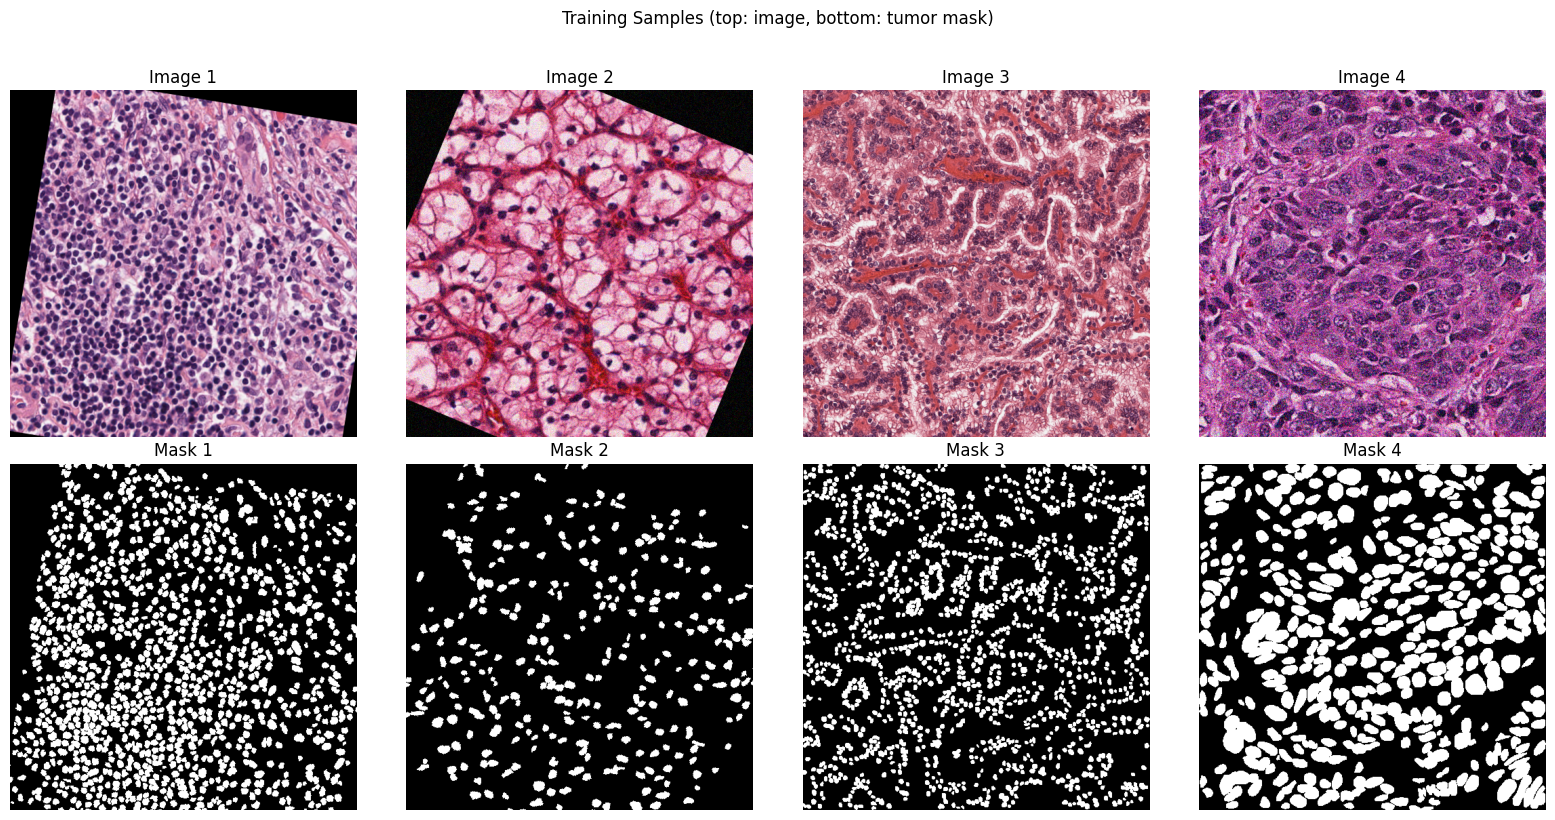

In [16]:
def denormalize(tensor):
    """Reverse ImageNet normalization for visualization."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return (tensor * std + mean).clamp(0, 1)

images, masks = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i in range(min(4, len(images))):
    img = denormalize(images[i]).permute(1,2,0).numpy()
    msk = masks[i].squeeze().numpy()
    axes[0, i].imshow(img)
    axes[0, i].set_title(f'Image {i+1}')
    axes[0, i].axis('off')
    axes[1, i].imshow(msk, cmap='gray')
    axes[1, i].set_title(f'Mask {i+1}')
    axes[1, i].axis('off')
plt.suptitle('Training Samples (top: image, bottom: tumor mask)', y=1.02)
plt.tight_layout()
plt.show()

## 4. FCN Model Architecture

**Structure:**
```
Input Image (3, 512, 512)
      │
  [ENCODER] ResNet-50 pretrained (frozen initially)
      │  Extracts rich feature maps at 1/32 resolution
      │
  [BOTTLENECK] ← THE LAYER TO BE REPLACED WITH QUANTUM?
      │  1x1 conv reducing channels, then expanding back
      │  Currently: ~262k params → quantum target: should be much lower from what I understood from the presentation
      │
  [DECODER] Bilinear upsampling back to original resolution
      │
  [HEAD] Sigmoid → binary mask (1, 512, 512)
```

In [17]:
class Bottleneck(nn.Module):
    """
    The bottleneck block.
    
    Input:  (B, in_channels, H, W)
    Output: (B, out_channels, H, W)
    """
    def __init__(self, in_channels, mid_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=0.3),
            nn.Conv2d(mid_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


class FCNSegmentation(nn.Module):
    """
    FCN-32s: ResNet-50 encoder + bottleneck + upsampling decoder.
    
    The encoder is pretrained on ImageNet. The bottleneck and decoder
    are trained from scratch on your pathology data.
    """
    def __init__(self, num_classes=1, pretrained=True):
        super().__init__()

        # Encoder: ResNet-50 (pretrained)
        resnet = models.resnet50(weights='IMAGENET1K_V2' if pretrained else None)
        # Remove the final avgpool and fc layers — we only need features
        self.encoder = nn.Sequential(
            resnet.conv1,    # (B, 64, H/2, W/2)
            resnet.bn1,
            resnet.relu,
            resnet.maxpool,  # (B, 64, H/4, W/4)
            resnet.layer1,   # (B, 256, H/4, W/4)
            resnet.layer2,   # (B, 512, H/8, W/8)
            resnet.layer3,   # (B, 1024, H/16, W/16)
            resnet.layer4,   # (B, 2048, H/32, W/32)
        )
        # Output of encoder: 2048 channels at 1/32 resolution

        # Bottleneck
        # in: 2048 ch → compress to 256 → expand to 256
        self.bottleneck = Bottleneck(
            in_channels=2048,
            mid_channels=256,
            out_channels=256
        )

        # Decoder: upsample back to full resolution
        self.decoder = nn.Sequential(
            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),  # /16

            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),  # /8

            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),  # /4

            nn.Conv2d(32, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),  # /2

            nn.Conv2d(16, 8, kernel_size=3, padding=1),
            nn.BatchNorm2d(8),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),  # /1
        )

        # Classification head
        self.head = nn.Sequential(
            nn.Conv2d(8, num_classes, kernel_size=1),
            nn.Sigmoid()   # Output: probability per pixel [0, 1]
        )

    def forward(self, x):
        x = self.encoder(x)       # Feature extraction
        x = self.bottleneck(x)    # Bottleneck
        x = self.decoder(x)       # Upsample to full resolution
        x = self.head(x)          # Binary prediction
        return x

    def freeze_encoder(self):
        """Freeze encoder weights — call at start of training."""
        for param in self.encoder.parameters():
            param.requires_grad = False
        print('Encoder frozen.')

    def unfreeze_encoder(self):
        """Unfreeze encoder — call after FREEZE_EPOCHS."""
        for param in self.encoder.parameters():
            param.requires_grad = True
        print('Encoder unfrozen.')

    def count_parameters(self):
        total     = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        bottleneck_params = self.bottleneck.count_parameters()
        print(f'Total params:          {total:,}')
        print(f'Trainable params:      {trainable:,}')
        print(f'Bottleneck params:     {bottleneck_params:,}')


# Build model
model = FCNSegmentation(num_classes=NUM_CLASSES, pretrained=True).to(DEVICE)
model.freeze_encoder()
model.count_parameters()

Encoder frozen.
Total params:          24,492,465
Trainable params:      984,433
Bottleneck params:     590,848


## 5. Loss Function
BCE + Dice loss.

In [18]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, pred, target):
        pred   = pred.view(-1)
        target = target.view(-1)
        intersection = (pred * target).sum()
        dice = (2. * intersection + self.smooth) / (pred.sum() + target.sum() + self.smooth)
        return 1 - dice


class CombinedLoss(nn.Module):
    """BCE + Dice. Alpha controls the weighting."""
    def __init__(self, alpha=0.5):
        super().__init__()
        self.bce  = nn.BCELoss()
        self.dice = DiceLoss()
        self.alpha = alpha

    def forward(self, pred, target):
        return self.alpha * self.bce(pred, target) + \
               (1 - self.alpha) * self.dice(pred, target)


criterion = CombinedLoss(alpha=0.5)
print('Loss function: 0.5 * BCE + 0.5 * Dice')

Loss function: 0.5 * BCE + 0.5 * Dice


## 6. Metrics

In [19]:
def compute_metrics(pred, target, threshold=0.5):
    """
    Compute Dice, IoU, Precision, Recall for a batch.
    pred:   (B, 1, H, W) float in [0, 1]
    target: (B, 1, H, W) float in {0, 1}
    """
    pred_bin = (pred > threshold).float()

    pred_flat   = pred_bin.view(-1).cpu().numpy()
    target_flat = target.view(-1).cpu().numpy()

    tp = ((pred_bin == 1) & (target == 1)).sum().item()
    fp = ((pred_bin == 1) & (target == 0)).sum().item()
    fn = ((pred_bin == 0) & (target == 1)).sum().item()
    tn = ((pred_bin == 0) & (target == 0)).sum().item()

    smooth = 1e-6
    dice      = (2 * tp + smooth) / (2 * tp + fp + fn + smooth)
    iou       = (tp + smooth) / (tp + fp + fn + smooth)
    precision = (tp + smooth) / (tp + fp + smooth)
    recall    = (tp + smooth) / (tp + fn + smooth)

    return {'dice': dice, 'iou': iou,
            'precision': precision, 'recall': recall}

print('Metrics: Dice, IoU, Precision, Recall')

Metrics: Dice, IoU, Precision, Recall


## 7. Training Loop

In [20]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    all_metrics = {'dice': 0, 'iou': 0, 'precision': 0, 'recall': 0}

    for images, masks in tqdm(loader, desc='Train', leave=False):
        images = images.to(device)
        masks  = masks.to(device)

        optimizer.zero_grad()
        preds = model(images)
        loss  = criterion(preds, masks)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        m = compute_metrics(preds.detach(), masks)
        for k in all_metrics:
            all_metrics[k] += m[k]

    n = len(loader)
    return total_loss / n, {k: v / n for k, v in all_metrics.items()}


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_metrics = {'dice': 0, 'iou': 0, 'precision': 0, 'recall': 0}

    for images, masks in tqdm(loader, desc='Val  ', leave=False):
        images = images.to(device)
        masks  = masks.to(device)

        preds = model(images)
        loss  = criterion(preds, masks)

        total_loss += loss.item()
        m = compute_metrics(preds, masks)
        for k in all_metrics:
            all_metrics[k] += m[k]

    n = len(loader)
    return total_loss / n, {k: v / n for k, v in all_metrics.items()}


# Optimizer: separate LR for encoder and rest
optimizer = optim.AdamW([
    {'params': model.encoder.parameters(),    'lr': LR_ENCODER},
    {'params': model.bottleneck.parameters(), 'lr': LR},
    {'params': model.decoder.parameters(),    'lr': LR},
    {'params': model.head.parameters(),       'lr': LR},
], weight_decay=WEIGHT_DECAY)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

print('Optimizer and scheduler ready.')

Optimizer and scheduler ready.


In [21]:
# Main training loop
history = {'train_loss': [], 'val_loss': [],
           'train_dice': [], 'val_dice': [],
           'train_iou':  [], 'val_iou':  []}

best_val_loss = float('inf')
no_improve    = 0

for epoch in range(1, NUM_EPOCHS + 1):

    # Gradually unfreeze encoder after FREEZE_EPOCHS
    if epoch == FREEZE_EPOCHS + 1:
        model.unfreeze_encoder()

    train_loss, train_m = train_one_epoch(
        model, train_loader, optimizer, criterion, DEVICE)
    val_loss,   val_m   = evaluate(
        model, val_loader,   criterion, DEVICE)

    scheduler.step()

    # Log
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_dice'].append(train_m['dice'])
    history['val_dice'].append(val_m['dice'])
    history['train_iou'].append(train_m['iou'])
    history['val_iou'].append(val_m['iou'])

    print(f'Epoch {epoch:03d}/{NUM_EPOCHS} | '
          f'Train Loss: {train_loss:.4f}  Dice: {train_m["dice"]:.4f}  IoU: {train_m["iou"]:.4f} | '
          f'Val   Loss: {val_loss:.4f}  Dice: {val_m["dice"]:.4f}  IoU: {val_m["iou"]:.4f}')

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        no_improve    = 0
        torch.save(model.state_dict(), SAVE_DIR / 'fcn_best.pth')
        print(f'  ✓ Best model saved (val_loss={val_loss:.4f})')
    else:
        no_improve += 1
        if no_improve >= EARLY_STOP:
            print(f'Early stopping at epoch {epoch}.')
            break

print('\nTraining complete.')

Epoch 001/50 | Train Loss: 0.6718  Dice: 0.2969  IoU: 0.1744 | Val   Loss: 0.6668  Dice: 0.0000  IoU: 0.0000
  ✓ Best model saved (val_loss=0.6668)


Epoch 002/50 | Train Loss: 0.6676  Dice: 0.3137  IoU: 0.1861 | Val   Loss: 0.6694  Dice: 0.0000  IoU: 0.0000


Epoch 003/50 | Train Loss: 0.6662  Dice: 0.3072  IoU: 0.1815 | Val   Loss: 0.6716  Dice: 0.0000  IoU: 0.0000


Epoch 004/50 | Train Loss: 0.6645  Dice: 0.3110  IoU: 0.1843 | Val   Loss: 0.6731  Dice: 0.0000  IoU: 0.0000


Epoch 005/50 | Train Loss: 0.6617  Dice: 0.3217  IoU: 0.1918 | Val   Loss: 0.6732  Dice: 0.0000  IoU: 0.0000
Encoder unfrozen.


...

Epoch 046/50 | Train Loss: 0.6420  Dice: 0.3689  IoU: 0.2264 | Val   Loss: 0.6552  Dice: 0.2989  IoU: 0.1757


Epoch 047/50 | Train Loss: 0.6424  Dice: 0.3782  IoU: 0.2336 | Val   Loss: 0.6556  Dice: 0.2962  IoU: 0.1739


Epoch 048/50 | Train Loss: 0.6450  Dice: 0.3625  IoU: 0.2219 | Val   Loss: 0.6560  Dice: 0.2834  IoU: 0.1651


Epoch 049/50 | Train Loss: 0.6439  Dice: 0.3672  IoU: 0.2252 | Val   Loss: 0.6558  Dice: 0.2674  IoU: 0.1543


Epoch 050/50 | Train Loss: 0.6425  Dice: 0.3573  IoU: 0.2177 | Val   Loss: 0.6565  Dice: 0.2766  IoU: 0.1605

Training complete.


## 8. Plot Training Curves

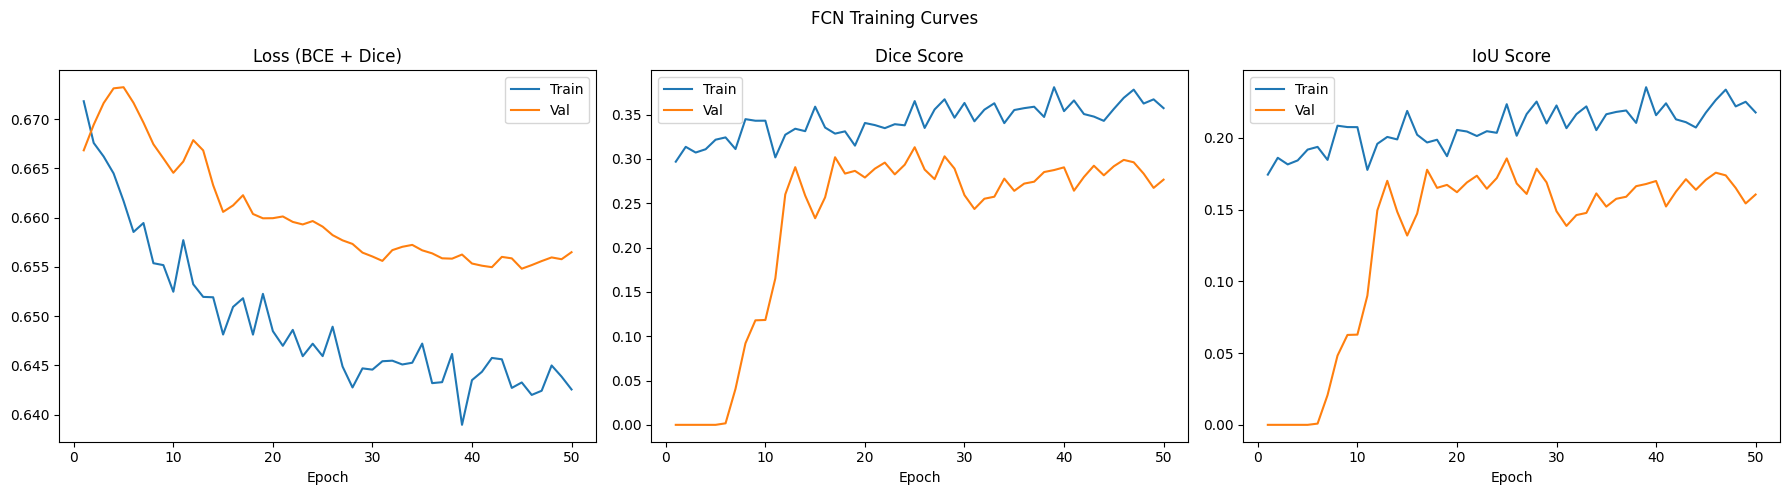

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
epochs = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs, history['train_loss'], label='Train')
axes[0].plot(epochs, history['val_loss'],   label='Val')
axes[0].set_title('Loss (BCE + Dice)')
axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(epochs, history['train_dice'], label='Train')
axes[1].plot(epochs, history['val_dice'],   label='Val')
axes[1].set_title('Dice Score')
axes[1].set_xlabel('Epoch'); axes[1].legend()

axes[2].plot(epochs, history['train_iou'], label='Train')
axes[2].plot(epochs, history['val_iou'],   label='Val')
axes[2].set_title('IoU Score')
axes[2].set_xlabel('Epoch'); axes[2].legend()

plt.suptitle('FCN Training Curves')
plt.tight_layout()
plt.savefig('fcn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Test Set Evaluation

In [23]:
# Load best model
model.load_state_dict(torch.load(SAVE_DIR / 'fcn_best.pth', map_location=DEVICE))
model.eval()

test_loss, test_metrics = evaluate(model, test_loader, criterion, DEVICE)

print('=' * 50)
print('FCN Test Set Results')
print('=' * 50)
print(f"Loss:      {test_loss:.4f}")
print(f"Dice:      {test_metrics['dice']:.4f}")
print(f"IoU:       {test_metrics['iou']:.4f}")
print(f"Precision: {test_metrics['precision']:.4f}")
print(f"Recall:    {test_metrics['recall']:.4f}")
print('=' * 50)

/tmp/ipykernel_1110357/3426315086.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(SAVE_DIR / 'fcn_best.pth', map_location=DEVICE))
     

FCN Test Set Results
Loss:      0.6681
Dice:      0.1616
IoU:       0.0936
Precision: 0.2316
Recall:    0.1586


## 10. Visualize Predictions

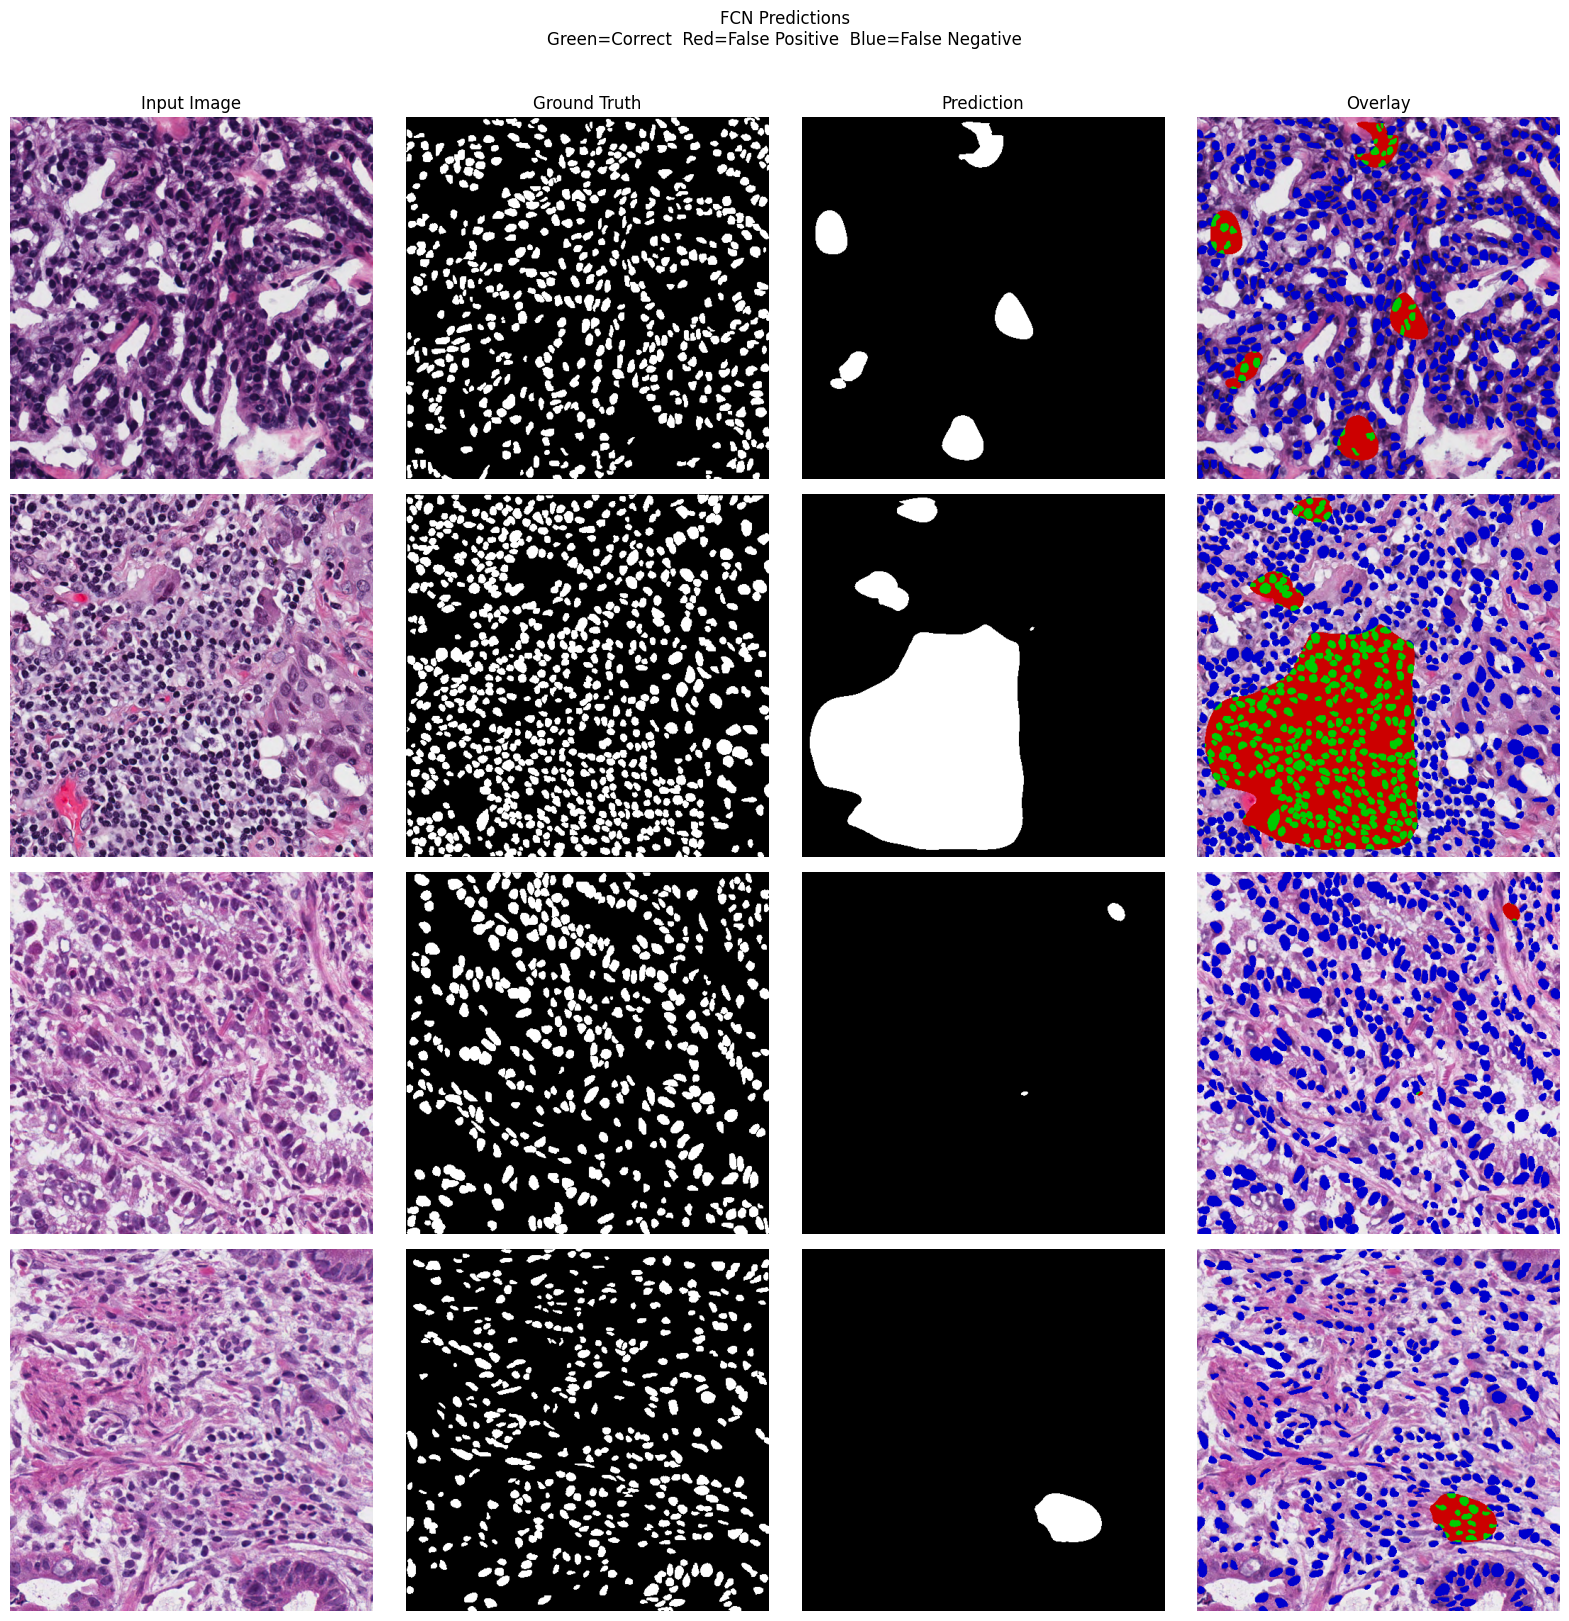

In [24]:
@torch.no_grad()
def visualize_predictions(model, loader, device, n=4, threshold=0.5):
    model.eval()
    images, masks = next(iter(loader))
    images_dev = images.to(device)
    preds = model(images_dev).cpu()
    preds_bin = (preds > threshold).float()

    fig, axes = plt.subplots(n, 4, figsize=(16, 4*n))
    cols = ['Input Image', 'Ground Truth', 'Prediction', 'Overlay']
    for ax, col in zip(axes[0], cols):
        ax.set_title(col, fontsize=12)

    for i in range(min(n, len(images))):
        img  = denormalize(images[i]).permute(1,2,0).numpy()
        gt   = masks[i].squeeze().numpy()
        pred = preds_bin[i].squeeze().numpy()

        # Overlay: green=TP, red=FP, blue=FN
        overlay = img.copy()
        tp = (pred == 1) & (gt == 1)
        fp = (pred == 1) & (gt == 0)
        fn = (pred == 0) & (gt == 1)
        overlay[tp] = [0.0, 0.8, 0.0]   # Green: correct
        overlay[fp] = [0.8, 0.0, 0.0]   # Red: false positive
        overlay[fn] = [0.0, 0.0, 0.8]   # Blue: false negative

        axes[i,0].imshow(img)
        axes[i,1].imshow(gt, cmap='gray')
        axes[i,2].imshow(pred, cmap='gray')
        axes[i,3].imshow(overlay)
        for ax in axes[i]: ax.axis('off')

    plt.suptitle('FCN Predictions\n'
                 'Green=Correct  Red=False Positive  Blue=False Negative',
                 y=1.01)
    plt.tight_layout()
    plt.savefig('fcn_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()

# visualize_predictions(model, test_loader, DEVICE, n=1)
viz_loader = DataLoader(test_dataset, batch_size=4,
                        shuffle=False, num_workers=2, pin_memory=True)
visualize_predictions(model, viz_loader, DEVICE, n=4)